In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as sta
import seaborn as sns
import sklearn as sk
from sklearn.metrics import mean_squared_error #MSE
from sklearn.metrics import mean_absolute_error #MAE
from sklearn.metrics import r2_score#R 2
from sklearn.neural_network import  MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
plt.rcParams['axes.unicode_minus'] =False
from warnings import filterwarnings
filterwarnings('ignore')


In [2]:
dff=pd.read_csv("C:/Users/15212/Austrailapvdataset.csv",skiprows=1,names=['时间','风速','摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','风向','每日降雨','总斜面辐照？','散射斜面辐照？','有功输送能量接收','平均相电流','性能比率','发电量'],engine='python')
# dff=pd.read_csv("C:/Users/15212/Austrailapvdataset.csv",engine='python')
#一般总辐照=散射辐照+直接辐照
# data=dff.values
dff.head()


,时间,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
0,2016/7/3 0:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.697554,1.407882,49697,0.3,0.0,0.0
1,2016/7/3 0:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.542039,1.323385,49697,0.3,0.0,0.0
2,2016/7/3 0:10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.600531,1.317494,49697,0.3,0.0,0.0
3,2016/7/3 0:15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.954946,1.143536,49697,0.3,0.0,0.0
4,2016/7/3 0:20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.920448,1.171720,49697,0.3,0.0,0.0


In [3]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590753 entries, 0 to 590752
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   时间        590753 non-null  object 
 1   风速        590753 non-null  float64
 2   摄氏气温      590753 non-null  float64
 3   相对湿度      590753 non-null  float64
 4   总地表水平辐照   590753 non-null  float64
 5   漫散地表水平辐照  590753 non-null  float64
 6   风向        590753 non-null  float64
 7   每日降雨      590753 non-null  float64
 8   总斜面辐照？    590753 non-null  float64
 9   散射斜面辐照？   590753 non-null  float64
 10  有功输送能量接收  590753 non-null  int64  
 11  平均相电流     590753 non-null  float64
 12  性能比率      590753 non-null  float64
 13  发电量       590753 non-null  float64
dtypes: float64(12), int64(1), object(1)
memory usage: 63.1+ MB


In [4]:
a=dff.iloc[864:3168]
# a=a.values
# print(np.shape(a))
a.head()


,时间,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
864,2016/7/6 0:00,0.928990,2.546587,93.824173,1.861109,1.305185,237.021332,0.0,1.813470,1.541264,49779,0.3,0.000000,0.000000
865,2016/7/6 0:05,0.904212,2.564368,95.311287,1.786773,1.169126,299.203308,0.0,1.766575,1.444233,49779,0.3,0.669110,0.000067
866,2016/7/6 0:10,0.871726,2.596964,95.923004,1.834076,1.197379,278.332581,0.0,1.644999,1.340842,49779,0.3,1.437124,0.000133
867,2016/7/6 0:15,0.974005,2.484001,94.966530,1.908230,1.235635,210.129578,0.0,1.759183,1.426481,49779,0.3,0.671922,0.000067
868,2016/7/6 0:20,1.183828,2.281204,94.785072,1.849337,1.192971,225.774551,0.0,1.913321,1.586180,49779,0.3,0.000000,0.000000


In [5]:
a.tail()

,时间,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
3163,2016/7/13 23:35,1.122348,2.405106,86.908661,2.229198,1.499524,205.526184,0.0,1.964181,1.552502,49972,0.3,0.0,0.0
3164,2016/7/13 23:40,1.047163,2.188474,87.388039,2.788598,2.029519,228.776688,0.0,1.645844,1.407708,49972,0.3,0.0,0.0
3165,2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.0,0.0
3166,2016/7/13 23:50,1.039778,1.924439,88.130760,2.432367,1.721340,261.493469,0.0,1.746500,1.316804,49972,0.3,0.0,0.0
3167,2016/7/13 23:55,0.951853,1.563130,88.421799,3.120748,2.406151,227.304413,0.0,1.515045,1.133832,49972,0.3,0.0,0.0


In [6]:
print((np.shape(a)))
for i in range(864,np.shape(a)[0]-1+864):
    if i%3!=0:
#         print(i)
        a.drop([i],axis=0,inplace=True)  


(2304, 14)


In [7]:
a.head(10)

,时间,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
864,2016/7/6 0:00,0.928990,2.546587,93.824173,1.861109,1.305185,237.021332,0.0,1.813470,1.541264,49779,0.300000,0.000000,0.000000
867,2016/7/6 0:15,0.974005,2.484001,94.966530,1.908230,1.235635,210.129578,0.0,1.759183,1.426481,49779,0.300000,0.671922,0.000067
870,2016/7/6 0:30,0.695020,2.509542,97.680908,1.841531,1.200872,230.030472,0.0,1.868202,1.553981,49779,0.300000,0.000000,0.000000
873,2016/7/6 0:45,1.262225,2.255296,95.827095,1.834772,1.175334,248.595367,0.0,2.180126,1.868229,49779,0.300000,0.000000,0.000000
876,2016/7/6 1:00,0.903179,2.024976,97.392868,2.277541,1.564485,269.722168,0.0,1.592316,1.438122,49779,0.300000,0.000000,0.000000
879,2016/7/6 1:15,0.918838,1.789979,99.671509,1.572325,0.960505,213.992783,0.0,1.471760,1.346969,49779,0.300000,0.000000,0.000000
882,2016/7/6 1:30,0.600105,1.759823,100.210922,2.458764,1.694412,188.615509,0.0,1.581696,1.317613,49779,0.300000,0.747320,0.000067
885,2016/7/6 1:45,1.004373,1.578810,100.607986,2.258248,1.487842,256.479584,0.0,1.669834,1.305596,49779,0.300667,0.707875,0.000067
888,2016/7/6 2:00,1.294062,1.163471,100.608177,1.805210,1.123652,238.705292,0.0,1.598850,1.295286,49779,0.300000,0.739302,0.000067
891,2016/7/6 2:15,1.158412,1.402787,0.000000,1.060395,0.558255,239.798752,0.0,1.559791,1.327724,49779,0.300000,0.000000,0.000000


In [8]:
b=a.values
a.index=b[:,0]
del a['时间']
a.head(6)



,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
2016/7/6 0:00,0.928990,2.546587,93.824173,1.861109,1.305185,237.021332,0.0,1.813470,1.541264,49779,0.3,0.000000,0.000000
2016/7/6 0:15,0.974005,2.484001,94.966530,1.908230,1.235635,210.129578,0.0,1.759183,1.426481,49779,0.3,0.671922,0.000067
2016/7/6 0:30,0.695020,2.509542,97.680908,1.841531,1.200872,230.030472,0.0,1.868202,1.553981,49779,0.3,0.000000,0.000000
2016/7/6 0:45,1.262225,2.255296,95.827095,1.834772,1.175334,248.595367,0.0,2.180126,1.868229,49779,0.3,0.000000,0.000000
2016/7/6 1:00,0.903179,2.024976,97.392868,2.277541,1.564485,269.722168,0.0,1.592316,1.438122,49779,0.3,0.000000,0.000000
2016/7/6 1:15,0.918838,1.789979,99.671509,1.572325,0.960505,213.992783,0.0,1.471760,1.346969,49779,0.3,0.000000,0.000000


In [9]:
dff.head()

,时间,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
0,2016/7/3 0:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.697554,1.407882,49697,0.3,0.0,0.0
1,2016/7/3 0:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.542039,1.323385,49697,0.3,0.0,0.0
2,2016/7/3 0:10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.600531,1.317494,49697,0.3,0.0,0.0
3,2016/7/3 0:15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.954946,1.143536,49697,0.3,0.0,0.0
4,2016/7/3 0:20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.920448,1.171720,49697,0.3,0.0,0.0


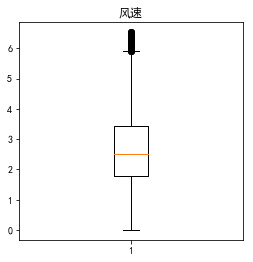

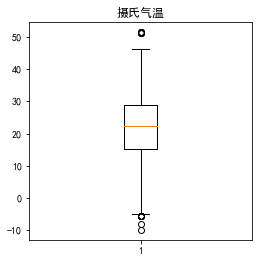

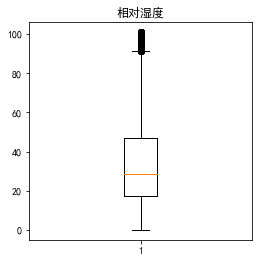

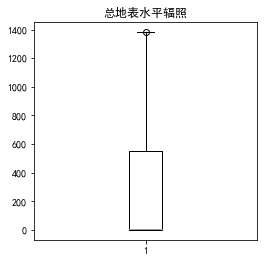

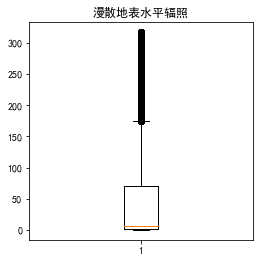

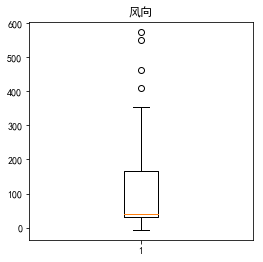

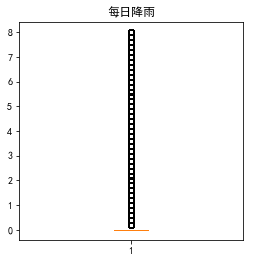

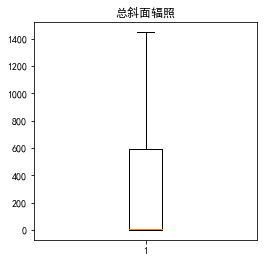

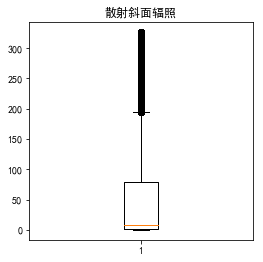

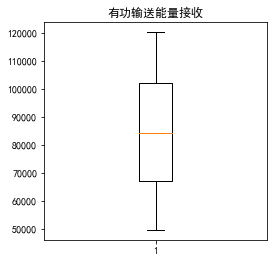

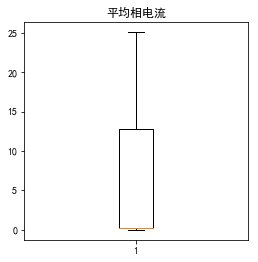

In [10]:
plt.rcParams['figure.figsize'] = (20.0, .0) # 单位是inches
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(4, 4))
plt.title('风速')
plt.boxplot(dff['风速'])
plt.savefig('a_box_speed.png')

plt.figure(figsize=(4, 4))
plt.title('摄氏气温')
plt.boxplot(dff['摄氏气温'])
plt.savefig('a_box_tem.png')

plt.figure(figsize=(4, 4))
plt.title('相对湿度')
plt.boxplot(dff['相对湿度'])
plt.savefig('a_box_humid.png')

plt.figure(figsize=(4, 4))
plt.title('总地表水平辐照')
plt.boxplot(dff['总地表水平辐照'])
plt.savefig('a_box_HR.png')

plt.figure(figsize=(4, 4))
plt.title('漫散地表水平辐照')
plt.boxplot(dff['漫散地表水平辐照'])
plt.savefig('a_box_HD.png')

plt.figure(figsize=(4, 4))
plt.title('风向')
plt.boxplot(dff['风向'])
plt.savefig('a_box_WDRECT.png')

plt.figure(figsize=(4, 4))
plt.title('每日降雨')
plt.boxplot(dff['每日降雨'])
plt.savefig('a_box_rainfall.png')

plt.figure(figsize=(4, 4))
plt.title('总斜面辐照')
plt.boxplot(dff['总斜面辐照？'])
plt.savefig('a_box_TR.png')

plt.figure(figsize=(4, 4))
plt.title('散射斜面辐照')
plt.boxplot(dff['散射斜面辐照？'])
plt.savefig('a_box_TD.png')

plt.figure(figsize=(4, 4))
plt.title('有功输送能量接收')
plt.boxplot(dff['有功输送能量接收'])
plt.savefig('a_box_energy.png')

plt.figure(figsize=(4, 4))
plt.title('平均相电流')
plt.boxplot(dff['平均相电流'])
# plt.figure(figsize=(4, 4))
# plt.boxplot(df['总地表水平辐照'])
plt.savefig('a_box_current.png')
plt.show()

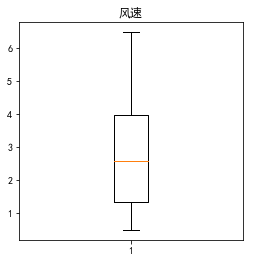

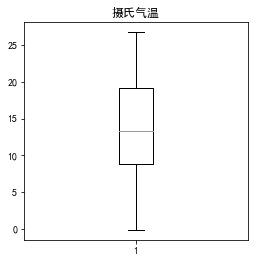

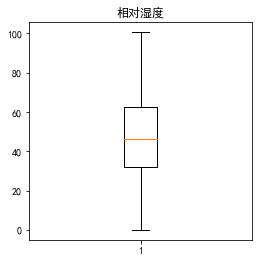

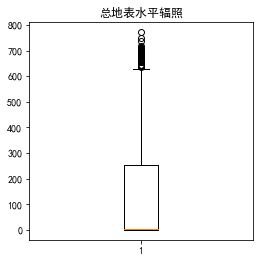

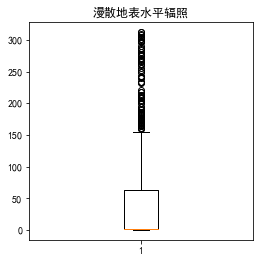

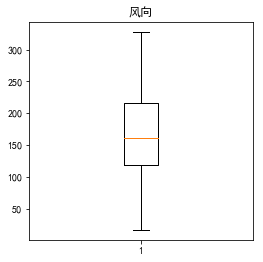

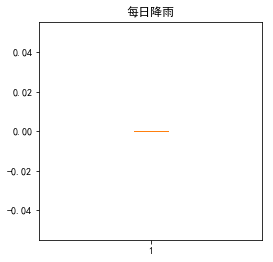

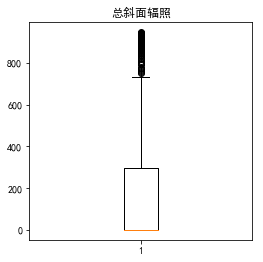

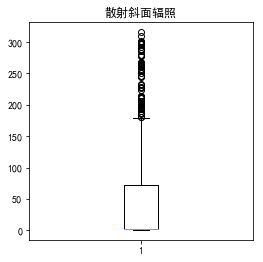

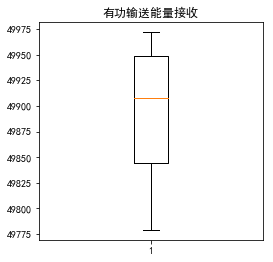

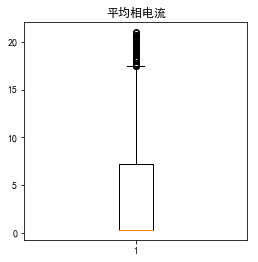

In [11]:
# '时间','风速','摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','风向','每日降雨','总斜面辐照？','
# 散射斜面辐照？','激活能源的收发？','现阶段平均？','性能比率','发电量'],engine='python')
plt.rcParams['figure.figsize'] = (20.0, .0) # 单位是inches
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(4, 4))
plt.title('风速')
plt.boxplot(a['风速'])

plt.figure(figsize=(4, 4))
plt.title('摄氏气温')
plt.boxplot(a['摄氏气温'])

plt.figure(figsize=(4, 4))
plt.title('相对湿度')
plt.boxplot(a['相对湿度'])

plt.figure(figsize=(4, 4))
plt.title('总地表水平辐照')
plt.boxplot(a['总地表水平辐照'])

plt.figure(figsize=(4, 4))
plt.title('漫散地表水平辐照')
plt.boxplot(a['漫散地表水平辐照'])

plt.figure(figsize=(4, 4))
plt.title('风向')
plt.boxplot(a['风向'])

plt.figure(figsize=(4, 4))
plt.title('每日降雨')
plt.boxplot(a['每日降雨'])

plt.figure(figsize=(4, 4))
plt.title('总斜面辐照')
plt.boxplot(a['总斜面辐照？'])

plt.figure(figsize=(4, 4))
plt.title('散射斜面辐照')
plt.boxplot(a['散射斜面辐照？'])

plt.figure(figsize=(4, 4))
plt.title('有功输送能量接收')
plt.boxplot(a['有功输送能量接收'])

plt.figure(figsize=(4, 4))
plt.title('平均相电流')
plt.boxplot(a['平均相电流'])
# plt.figure(figsize=(4, 4))
# plt.boxplot(df['总地表水平辐照'])
plt.show()


In [12]:
# 去除不正常的0值
col=a['相对湿度']
a.drop(a[np.abs(col)==0].index,inplace=True)
a.drop(a[np.abs(col)>100].index,inplace=True)
col=a['摄氏气温']
a.drop(a[np.abs(col)==0].index,inplace=True)

col=a['总地表水平辐照']
a.drop(a[np.abs(col)==0].index,inplace=True)

col=a['漫散地表水平辐照']
a.drop(a[np.abs(col)==0].index,inplace=True)

col=a['风向']
a.drop(a[np.abs(col)==0].index,inplace=True)
a.drop(a[np.abs(col)>360].index,inplace=True)
# col=df['总地表水平辐照']
# df.drop(df[np.abs(col)==0].index,inplace=True)

# col=df['总地表水平辐照']
# df.drop(df[np.abs(col)==0].index,inplace=True)

# col=df['总地表水平辐照']
# df.drop(df[np.abs(col)==0].index,inplace=True)

# col=df['总地表水平辐照']
# df.drop(df[np.abs(col)==0].index,inplace=True)



# plt.figure(figsize=(4, 4))
# plt.title('激活能源的收发')
# plt.boxplot(df['激活能源的收发？'])

# plt.figure(figsize=(4, 4))
# plt.title('现阶段平均')
# plt.boxplot(df['现阶段平均？'])

a.head(50)

,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
2016/7/6 0:00,0.928990,2.546587,93.824173,1.861109,1.305185,237.021332,0.0,1.813470,1.541264,49779,0.300000,0.000000,0.000000
2016/7/6 0:15,0.974005,2.484001,94.966530,1.908230,1.235635,210.129578,0.0,1.759183,1.426481,49779,0.300000,0.671922,0.000067
2016/7/6 0:30,0.695020,2.509542,97.680908,1.841531,1.200872,230.030472,0.0,1.868202,1.553981,49779,0.300000,0.000000,0.000000
2016/7/6 0:45,1.262225,2.255296,95.827095,1.834772,1.175334,248.595367,0.0,2.180126,1.868229,49779,0.300000,0.000000,0.000000
2016/7/6 1:00,0.903179,2.024976,97.392868,2.277541,1.564485,269.722168,0.0,1.592316,1.438122,49779,0.300000,0.000000,0.000000
2016/7/6 1:15,0.918838,1.789979,99.671509,1.572325,0.960505,213.992783,0.0,1.471760,1.346969,49779,0.300000,0.000000,0.000000
2016/7/6 8:15,0.708161,4.255711,93.702164,132.055420,27.950859,192.075821,0.0,252.705139,25.082661,49780,5.954000,96.342850,1.373133
2016/7/6 8:30,1.893553,5.597556,80.627121,135.351654,30.542458,157.470444,0.0,320.237976,31.954266,49780,7.607333,98.572906,1.780367
2016/7/6 8:45,1.138911,6.705988,72.376442,272.381409,33.782642,145.147369,0.0,382.427826,35.885670,49781,9.156334,99.785515,2.152267
2016/7/6 9:00,1.409197,7.929681,65.543411,346.519196,33.518837,88.230309,0.0,444.206024,40.573204,49781,10.611666,100.259903,2.511833


In [13]:
a.tail(97)

,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
2016/7/13 0:00,1.606832,8.284618,54.894066,1.728860,1.342126,181.911087,0.0,1.562674,1.486305,49962,0.3,0.000000,0.000000
2016/7/13 0:15,1.645770,8.161630,54.839531,1.713017,1.185592,148.216537,0.0,1.511738,2.021634,49962,0.3,0.000000,0.000000
2016/7/13 0:30,1.931330,8.077277,54.849476,1.620283,1.146561,159.223465,0.0,1.822753,1.561777,49962,0.3,0.000000,0.000000
2016/7/13 0:45,1.717924,8.101665,55.115501,1.526800,1.001780,131.557739,0.0,1.443483,1.345999,49962,0.3,0.818875,0.000067
2016/7/13 1:00,1.898170,8.166620,55.297089,1.450766,0.927180,139.019241,0.0,1.486449,1.369577,49962,0.3,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016/7/13 23:00,1.416306,3.340456,83.819626,1.751923,1.200710,184.438339,0.0,1.767179,1.486121,49972,0.3,0.000000,0.000000
2016/7/13 23:15,1.002203,3.479267,83.384705,1.586302,0.988847,177.263382,0.0,1.655510,1.335626,49972,0.3,0.000000,0.000000
2016/7/13 23:30,1.096549,2.573719,85.902855,2.603107,1.925054,230.218582,0.0,2.239897,1.866155,49972,0.3,0.000000,0.000000
2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.000000,0.000000


In [14]:
a.tail(193)

,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
2016/7/12 0:00,1.160720,10.000432,57.948105,1.996637,1.431905,265.729004,0.0,1.899596,1.821619,49949,0.3,0.0,0.0
2016/7/12 0:15,0.968325,9.618408,59.460293,2.126210,1.606969,16.436953,0.0,1.777685,1.759294,49949,0.3,0.0,0.0
2016/7/12 0:30,1.218806,9.461571,61.101059,1.477783,0.905921,292.793518,0.0,1.517347,1.470485,49949,0.3,0.0,0.0
2016/7/12 0:45,0.855749,9.382223,59.895798,1.613481,1.117108,249.961044,0.0,1.454937,1.356103,49949,0.3,0.0,0.0
2016/7/12 1:00,0.711994,9.154008,60.342133,1.529624,1.043624,219.137604,0.0,1.606698,1.610186,49949,0.3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016/7/13 23:00,1.416306,3.340456,83.819626,1.751923,1.200710,184.438339,0.0,1.767179,1.486121,49972,0.3,0.0,0.0
2016/7/13 23:15,1.002203,3.479267,83.384705,1.586302,0.988847,177.263382,0.0,1.655510,1.335626,49972,0.3,0.0,0.0
2016/7/13 23:30,1.096549,2.573719,85.902855,2.603107,1.925054,230.218582,0.0,2.239897,1.866155,49972,0.3,0.0,0.0
2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.0,0.0


In [15]:
a.tail(289)

,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
2016/7/11 0:00,1.221341,13.551605,80.948204,1.713748,1.320104,23.116426,0.0,1.546718,1.640737,49926,0.3,0.0,0.0
2016/7/11 0:15,0.940488,13.220404,82.491074,1.762588,1.321943,16.436953,0.0,1.321486,1.504969,49926,0.3,0.0,0.0
2016/7/11 0:30,0.795513,13.429848,82.128090,1.359784,0.892070,59.576828,0.0,1.405362,1.539844,49926,0.3,0.0,0.0
2016/7/11 0:45,0.999107,13.407080,81.989433,1.510238,1.078705,100.737640,0.0,1.480432,1.510806,49926,0.3,0.0,0.0
2016/7/11 1:00,1.159640,13.267263,82.429962,1.665388,1.198886,63.630497,0.0,1.481408,1.603363,49926,0.3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016/7/13 23:00,1.416306,3.340456,83.819626,1.751923,1.200710,184.438339,0.0,1.767179,1.486121,49972,0.3,0.0,0.0
2016/7/13 23:15,1.002203,3.479267,83.384705,1.586302,0.988847,177.263382,0.0,1.655510,1.335626,49972,0.3,0.0,0.0
2016/7/13 23:30,1.096549,2.573719,85.902855,2.603107,1.925054,230.218582,0.0,2.239897,1.866155,49972,0.3,0.0,0.0
2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.0,0.0


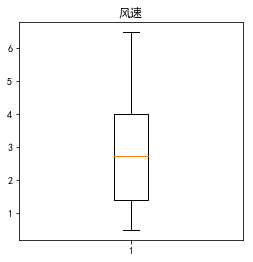

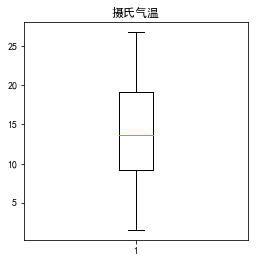

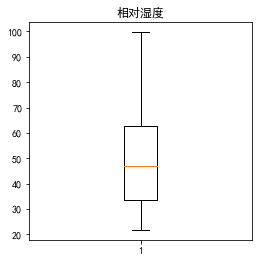

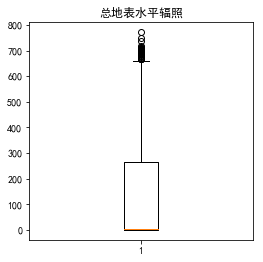

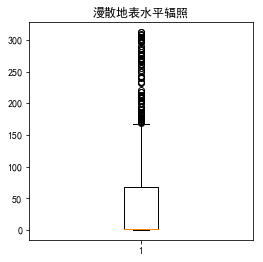

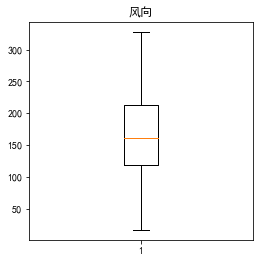

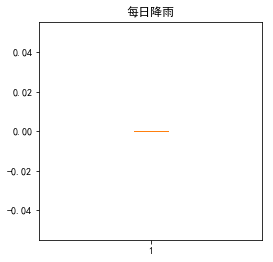

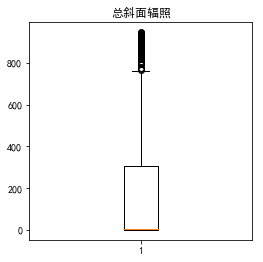

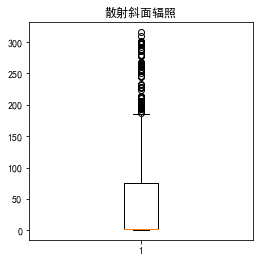

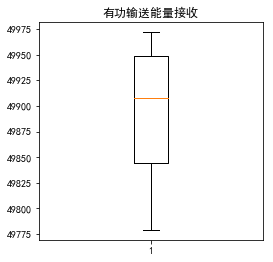

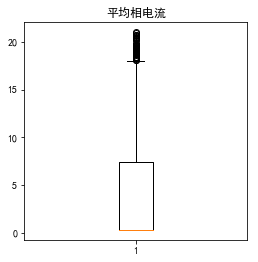

In [16]:
plt.rcParams['figure.figsize'] = (20.0, .0) # 单位是inches
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.figure(figsize=(4, 4))
plt.title('风速')
plt.boxplot(a['风速'])

plt.figure(figsize=(4, 4))
plt.title('摄氏气温')
plt.boxplot(a['摄氏气温'])

plt.figure(figsize=(4, 4))
plt.title('相对湿度')
plt.boxplot(a['相对湿度'])

plt.figure(figsize=(4, 4))
plt.title('总地表水平辐照')
plt.boxplot(a['总地表水平辐照'])

plt.figure(figsize=(4, 4))
plt.title('漫散地表水平辐照')
plt.boxplot(a['漫散地表水平辐照'])

plt.figure(figsize=(4, 4))
plt.title('风向')
plt.boxplot(a['风向'])

plt.figure(figsize=(4, 4))
plt.title('每日降雨')
plt.boxplot(a['每日降雨'])

plt.figure(figsize=(4, 4))
plt.title('总斜面辐照')
plt.boxplot(a['总斜面辐照？'])

plt.figure(figsize=(4, 4))
plt.title('散射斜面辐照')
plt.boxplot(a['散射斜面辐照？'])

plt.figure(figsize=(4, 4))
plt.title('有功输送能量接收')
plt.boxplot(a['有功输送能量接收'])

plt.figure(figsize=(4, 4))
plt.title('平均相电流')
plt.boxplot(a['平均相电流'])
# plt.figure(figsize=(4, 4))
# plt.boxplot(df['总地表水平辐照'])
plt.show()


In [17]:
a.corr()['发电量']

风速          0.465655
摄氏气温        0.455082
相对湿度       -0.538826
总地表水平辐照     0.994877
漫散地表水平辐照    0.507366
风向         -0.044887
每日降雨             NaN
总斜面辐照？      0.996823
散射斜面辐照？     0.560718
有功输送能量接收   -0.260999
平均相电流       0.999707
性能比率        0.781471
发电量         1.000000
Name: 发电量, dtype: float64

In [18]:
a.corr()['性能比率']

风速          0.514949
摄氏气温        0.372481
相对湿度       -0.510179
总地表水平辐照     0.791180
漫散地表水平辐照    0.762275
风向         -0.036791
每日降雨             NaN
总斜面辐照？      0.768769
散射斜面辐照？     0.798189
有功输送能量接收   -0.022236
平均相电流       0.786856
性能比率        1.000000
发电量         0.781471
Name: 性能比率, dtype: float64

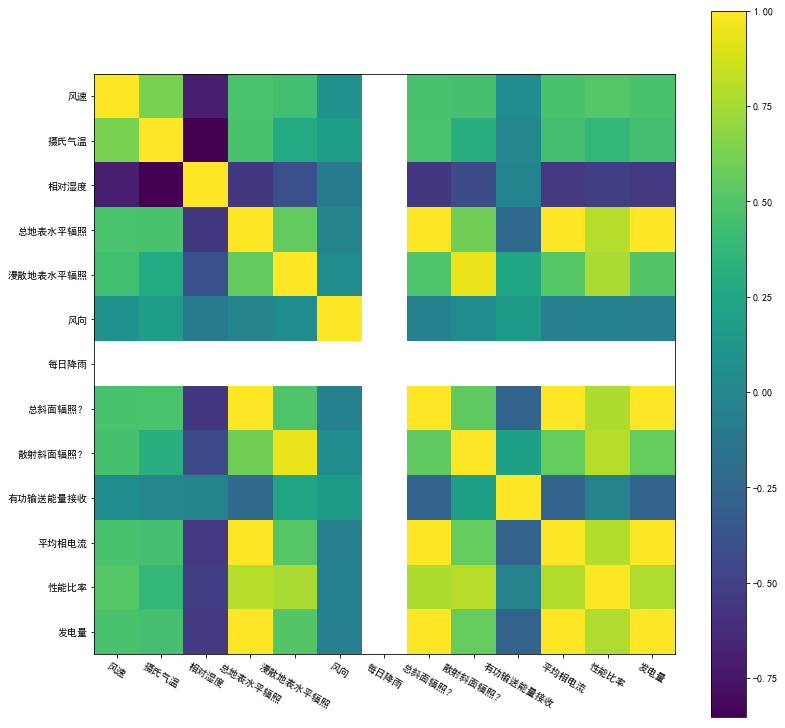

In [19]:
corr=a.corr()
import matplotlib.pyplot as plt
label=['Open','High','Low','Close','Adj Close','Volume','MC']
fig = plt.figure(figsize=(13,13))
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],['风速','摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','风向','每日降雨','总斜面辐照？','散射斜面辐照？','有功输送能量接收','平均相电流','性能比率','发电量'],rotation = -30)
# plt.xticks([0],['性能比率'])
plt.yticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],['风速','摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','风向','每日降雨','总斜面辐照？','散射斜面辐照？','有功输送能量接收','平均相电流','性能比率','发电量'])
corr_value=corr.values
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.imshow(corr)
plt.colorbar()


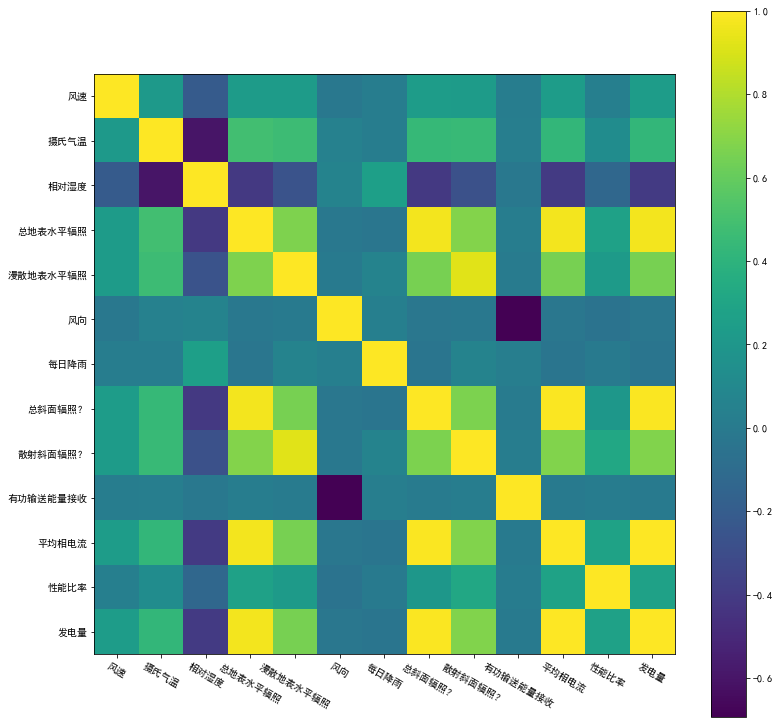

In [20]:
corr=dff.corr()
import matplotlib.pyplot as plt
label=['Open','High','Low','Close','Adj Close','Volume','MC']
fig = plt.figure(figsize=(13,13))
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],['风速','摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','风向','每日降雨','总斜面辐照？','散射斜面辐照？','有功输送能量接收','平均相电流','性能比率','发电量'],rotation = -30)
# plt.xticks([0],['性能比率'])
plt.yticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13],['风速','摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','风向','每日降雨','总斜面辐照？','散射斜面辐照？','有功输送能量接收','平均相电流','性能比率','发电量'])
corr_value=corr.values
plt.rcParams['font.sans-serif'] = ['SimHei']
# plt.savefig('coor.png')
plt.imshow(corr)
plt.savefig('coor.png')
plt.colorbar()
plt.savefig('bar.png')

In [21]:
#归一化
an2=a
an2 = (an2 - an2.min()) / (an2.max() - an2.min())
# print(dfn2)
an2.head()

,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
2016/7/6 0:00,0.071637,0.039050,0.924959,0.002011,0.002954,0.709829,NaN,0.001405,0.002377,0.0,0.0,0.016935,0.000168
2016/7/6 0:15,0.079154,0.036565,0.939619,0.002072,0.002731,0.623293,NaN,0.001348,0.002013,0.0,0.0,0.022156,0.000181
2016/7/6 0:30,0.032567,0.037579,0.974454,0.001985,0.002619,0.687333,NaN,0.001463,0.002418,0.0,0.0,0.016935,0.000168
2016/7/6 0:45,0.127284,0.027484,0.950663,0.001977,0.002537,0.747074,NaN,0.001793,0.003416,0.0,0.0,0.016935,0.000168
2016/7/6 1:00,0.067327,0.018339,0.970757,0.002551,0.003786,0.815059,NaN,0.001171,0.002050,0.0,0.0,0.016935,0.000168


In [22]:
aa=a.reset_index(inplace=False)

In [23]:
aa.head()

,index,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
0,2016/7/6 0:00,0.928990,2.546587,93.824173,1.861109,1.305185,237.021332,0.0,1.813470,1.541264,49779,0.3,0.000000,0.000000
1,2016/7/6 0:15,0.974005,2.484001,94.966530,1.908230,1.235635,210.129578,0.0,1.759183,1.426481,49779,0.3,0.671922,0.000067
2,2016/7/6 0:30,0.695020,2.509542,97.680908,1.841531,1.200872,230.030472,0.0,1.868202,1.553981,49779,0.3,0.000000,0.000000
3,2016/7/6 0:45,1.262225,2.255296,95.827095,1.834772,1.175334,248.595367,0.0,2.180126,1.868229,49779,0.3,0.000000,0.000000
4,2016/7/6 1:00,0.903179,2.024976,97.392868,2.277541,1.564485,269.722168,0.0,1.592316,1.438122,49779,0.3,0.000000,0.000000


In [24]:
aa.tail(289)

,index,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
453,2016/7/11 0:00,1.221341,13.551605,80.948204,1.713748,1.320104,23.116426,0.0,1.546718,1.640737,49926,0.3,0.0,0.0
454,2016/7/11 0:15,0.940488,13.220404,82.491074,1.762588,1.321943,16.436953,0.0,1.321486,1.504969,49926,0.3,0.0,0.0
455,2016/7/11 0:30,0.795513,13.429848,82.128090,1.359784,0.892070,59.576828,0.0,1.405362,1.539844,49926,0.3,0.0,0.0
456,2016/7/11 0:45,0.999107,13.407080,81.989433,1.510238,1.078705,100.737640,0.0,1.480432,1.510806,49926,0.3,0.0,0.0
457,2016/7/11 1:00,1.159640,13.267263,82.429962,1.665388,1.198886,63.630497,0.0,1.481408,1.603363,49926,0.3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,2016/7/13 23:00,1.416306,3.340456,83.819626,1.751923,1.200710,184.438339,0.0,1.767179,1.486121,49972,0.3,0.0,0.0
738,2016/7/13 23:15,1.002203,3.479267,83.384705,1.586302,0.988847,177.263382,0.0,1.655510,1.335626,49972,0.3,0.0,0.0
739,2016/7/13 23:30,1.096549,2.573719,85.902855,2.603107,1.925054,230.218582,0.0,2.239897,1.866155,49972,0.3,0.0,0.0
740,2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.0,0.0


In [25]:
aa.tail(193)

,index,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
549,2016/7/12 0:00,1.160720,10.000432,57.948105,1.996637,1.431905,265.729004,0.0,1.899596,1.821619,49949,0.3,0.0,0.0
550,2016/7/12 0:15,0.968325,9.618408,59.460293,2.126210,1.606969,16.436953,0.0,1.777685,1.759294,49949,0.3,0.0,0.0
551,2016/7/12 0:30,1.218806,9.461571,61.101059,1.477783,0.905921,292.793518,0.0,1.517347,1.470485,49949,0.3,0.0,0.0
552,2016/7/12 0:45,0.855749,9.382223,59.895798,1.613481,1.117108,249.961044,0.0,1.454937,1.356103,49949,0.3,0.0,0.0
553,2016/7/12 1:00,0.711994,9.154008,60.342133,1.529624,1.043624,219.137604,0.0,1.606698,1.610186,49949,0.3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,2016/7/13 23:00,1.416306,3.340456,83.819626,1.751923,1.200710,184.438339,0.0,1.767179,1.486121,49972,0.3,0.0,0.0
738,2016/7/13 23:15,1.002203,3.479267,83.384705,1.586302,0.988847,177.263382,0.0,1.655510,1.335626,49972,0.3,0.0,0.0
739,2016/7/13 23:30,1.096549,2.573719,85.902855,2.603107,1.925054,230.218582,0.0,2.239897,1.866155,49972,0.3,0.0,0.0
740,2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.0,0.0


In [26]:
aa.tail(97)

,index,风速,摄氏气温,相对湿度,总地表水平辐照,漫散地表水平辐照,风向,每日降雨,总斜面辐照？,散射斜面辐照？,有功输送能量接收,平均相电流,性能比率,发电量
645,2016/7/13 0:00,1.606832,8.284618,54.894066,1.728860,1.342126,181.911087,0.0,1.562674,1.486305,49962,0.3,0.000000,0.000000
646,2016/7/13 0:15,1.645770,8.161630,54.839531,1.713017,1.185592,148.216537,0.0,1.511738,2.021634,49962,0.3,0.000000,0.000000
647,2016/7/13 0:30,1.931330,8.077277,54.849476,1.620283,1.146561,159.223465,0.0,1.822753,1.561777,49962,0.3,0.000000,0.000000
648,2016/7/13 0:45,1.717924,8.101665,55.115501,1.526800,1.001780,131.557739,0.0,1.443483,1.345999,49962,0.3,0.818875,0.000067
649,2016/7/13 1:00,1.898170,8.166620,55.297089,1.450766,0.927180,139.019241,0.0,1.486449,1.369577,49962,0.3,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,2016/7/13 23:00,1.416306,3.340456,83.819626,1.751923,1.200710,184.438339,0.0,1.767179,1.486121,49972,0.3,0.000000,0.000000
738,2016/7/13 23:15,1.002203,3.479267,83.384705,1.586302,0.988847,177.263382,0.0,1.655510,1.335626,49972,0.3,0.000000,0.000000
739,2016/7/13 23:30,1.096549,2.573719,85.902855,2.603107,1.925054,230.218582,0.0,2.239897,1.866155,49972,0.3,0.000000,0.000000
740,2016/7/13 23:45,0.998802,2.130363,88.801155,2.150451,1.425259,254.294083,0.0,1.838619,1.431119,49972,0.3,0.000000,0.000000


In [27]:
from sklearn import metrics
# mean_squared_error, mean_absolute_error, r2_score

In [28]:
from sklearn.model_selection import train_test_split
y=aa['发电量'].values
cols=['摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','总斜面辐照？','散射斜面辐照？','发电量']
# cols=['摄氏气温','相对湿度','总地表水平辐照','漫散地表水平辐照','总斜面辐照？','散射斜面辐照？','平均相电流','性能比率','发电量']
x=aa[cols].values

In [29]:
# print(np.shape(x))

In [30]:
# x_train1,x_test1, y_train1, y_test1 =train_test_split(x,y,test_size=0.1248, shuffle= False)



In [199]:
from sklearn.neural_network import  MLPRegressor
mlp96 = MLPRegressor(hidden_layer_sizes=(600,600), activation='logistic', solver='lbfgs',max_iter=1000)
mlp96.fit(x[453:549], y[453:549])
mlp192 = MLPRegressor(hidden_layer_sizes=(600,600), activation='logistic', solver='lbfgs',max_iter=1000)
mlp192.fit(x[453:645], y[453:645])
# print(y[453:645])

MLPRegressor(activation='logistic', alpha=0.0001, batch_size='auto',
       beta_1=0.9, beta_2=0.999, early_stopping=False, epsilon=1e-08,
       hidden_layer_sizes=(600, 600), learning_rate='constant',
       learning_rate_init=0.001, max_iter=1000, momentum=0.9,
       nesterovs_momentum=True, power_t=0.5, random_state=None,
       shuffle=True, solver='lbfgs', tol=0.0001, validation_fraction=0.1,
       verbose=False, warm_start=False)

In [200]:
y96 = mlp96.predict(x[645:])
mse1=mean_squared_error(y[645:],y96)
nmse1=np.sqrt(mse1)  # RMSE
mae1=mean_absolute_error(y[645:],y96)
r2_1=r2_score(y[645:],y96)
print('NMSE:\n', nmse1)
print('MAE:\n', mae1)
print('R2:\n', r2_1)
# print('R2:\n', mpl.score(x_test, y_test))

NMSE:
 0.10914169917450449
MAE:
 0.059423406229411294
R2:
 0.9686748936255639


In [201]:
y192 = mlp192.predict(x[645:])
mse2=mean_squared_error(y[645:],y192)
nmse2=np.sqrt(mse2)  # RMSE
mae2=mean_absolute_error(y[645:],y192)
r2_2=r2_score(y[645:],y192)
print('NMSE:\n', nmse2)
print('MAE:\n', mae2)
print('R2:\n', r2_2)
# print('R2:\n', mpl.score(x_test, y_test))

NMSE:
 0.06534984603189124
MAE:
 0.03459582840575931
R2:
 0.9887694695373997


In [129]:
knn96 = KNeighborsRegressor(n_neighbors=5) 
knn96.fit(x[453:549], y[453:549])
knn192 = KNeighborsRegressor(n_neighbors=5) 
knn192.fit(x[453:645], y[453:645])

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
          metric_params=None, n_jobs=1, n_neighbors=5, p=2,
          weights='uniform')

In [130]:
# y96knn = knn.predict(x_test)
# mse=mean_squared_error(y_test,y_pre_knn)
# nmse=np.sqrt(mse)  # RMSE
# mae=mean_absolute_error(y_test,y_pre_knn)
# r2=r2_score(y_test,y_pre_knn)
# print('NMSE:\n', nmse)
# print('MAE:\n', mae)
# print('R2:\n', r2)
y96knn = knn96.predict(x[645:])
mse3=mean_squared_error(y[645:],y96knn)
nmse3=np.sqrt(mse3)  # RMSE
mae3=mean_absolute_error(y[645:],y96knn)
r2_3=r2_score(y[645:],y96knn)
print('NMSE:\n', nmse3)
print('MAE:\n', mae3)
print('R2:\n', r2_3)
# print('R2:\n', mpl.score(x_test, y_test))

NMSE:
 0.0686896855202577
MAE:
 0.038327651847422664
R2:
 0.9875922170155421


In [131]:
y192knn = knn192.predict(x[645:])
mse4=mean_squared_error(y[645:],y192knn)
nmse4=np.sqrt(mse4)  # RMSE
mae4=mean_absolute_error(y[645:],y192knn)
r2_4=r2_score(y[645:],y192knn)
print('NMSE:\n', nmse4)
print('MAE:\n', mae4)
print('R2:\n', r2_4)

NMSE:
 0.042508371289788564
MAE:
 0.02187099615463918
R2:
 0.9952481791001205


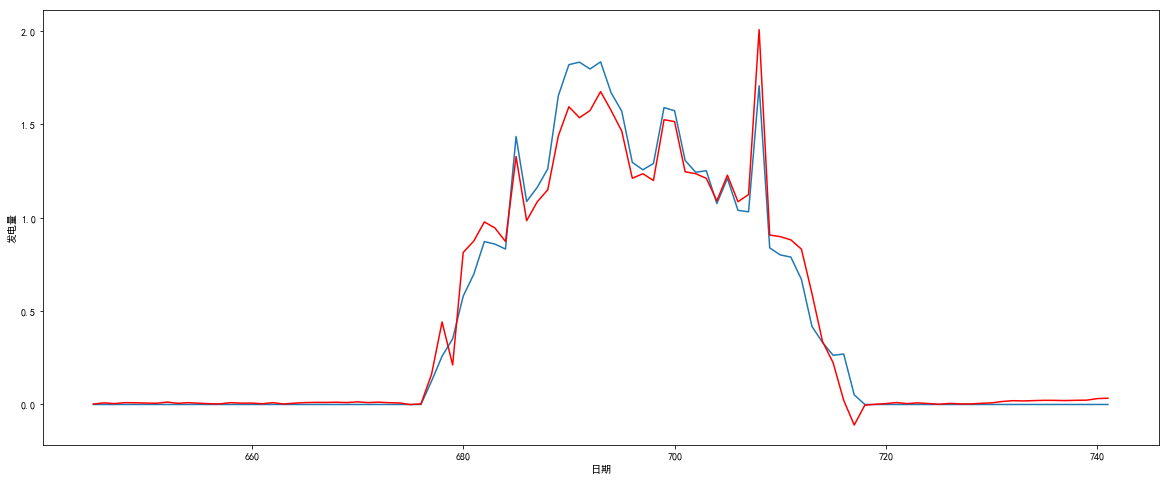

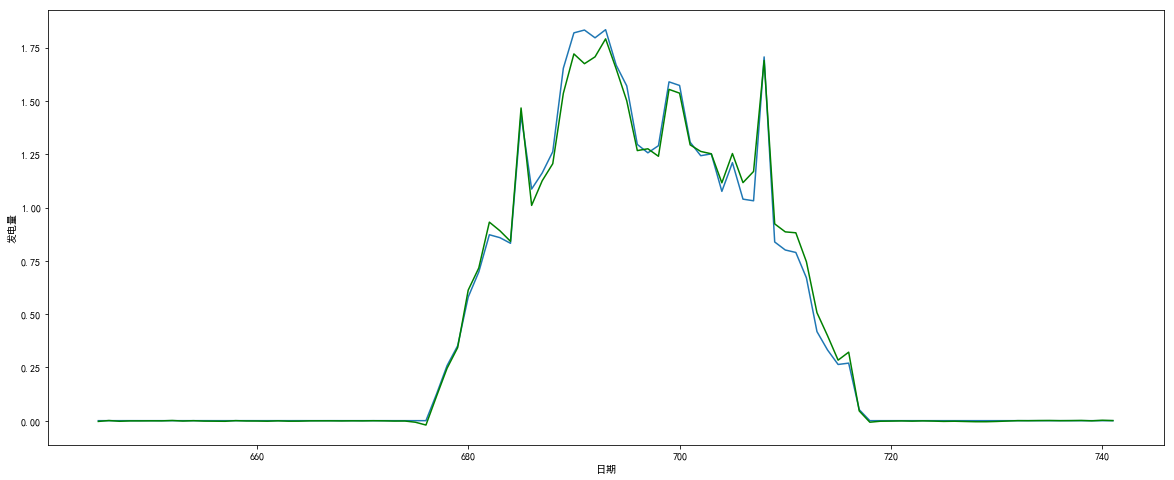

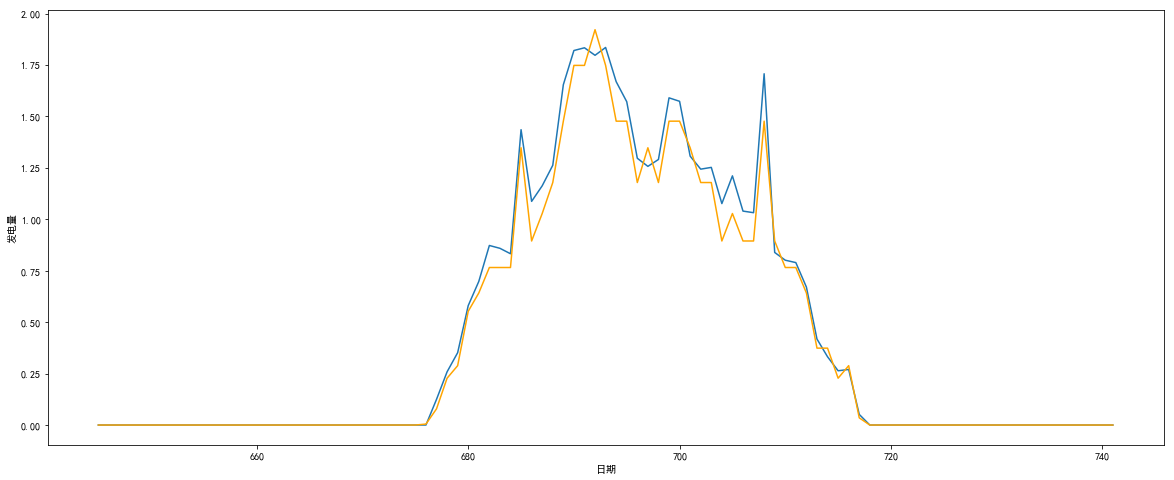

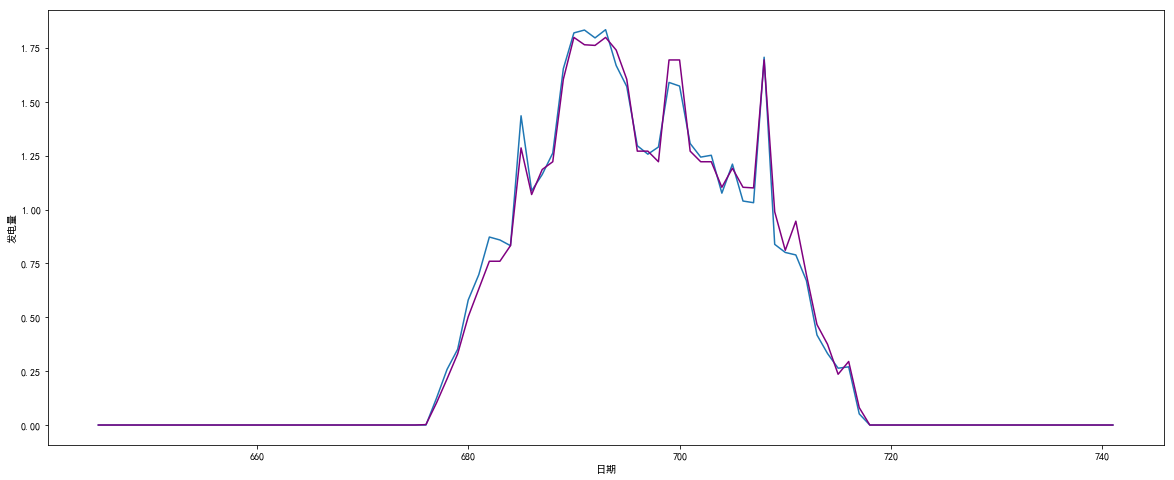

In [184]:
# a.index=pd.to_datetime(a.index)
# x[453:549], y[453:549]
fig = plt.figure(figsize=(20,8))
plt.plot(aa[645:].index,y[645:])
plt.plot(aa[645:].index,y96,color='red')
plt.xlabel("日期")
plt.ylabel("发电量")
plt.savefig('y96.png')
fig = plt.figure(figsize=(20,8))
plt.plot(aa[645:].index,y[645:])
plt.plot(aa[645:].index,y192,color='green')
plt.xlabel("日期")
plt.ylabel("发电量")
plt.savefig('y192.png')
fig = plt.figure(figsize=(20,8))
plt.plot(aa[645:].index,y[645:])
plt.plot(aa[645:].index,y96knn,color='orange')
plt.xlabel("日期")
plt.ylabel("发电量")
plt.savefig('y96knn.png')
fig = plt.figure(figsize=(20,8))
plt.plot(aa[645:].index,y[645:])
plt.plot(aa[645:].index,y192knn,color='purple')
plt.xlabel("日期")
plt.ylabel("发电量")
# plt.rcParams['figure.figsize'] = (200.0, 200.0) # 单位是inches
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.savefig('y192knn.png')
plt.show()

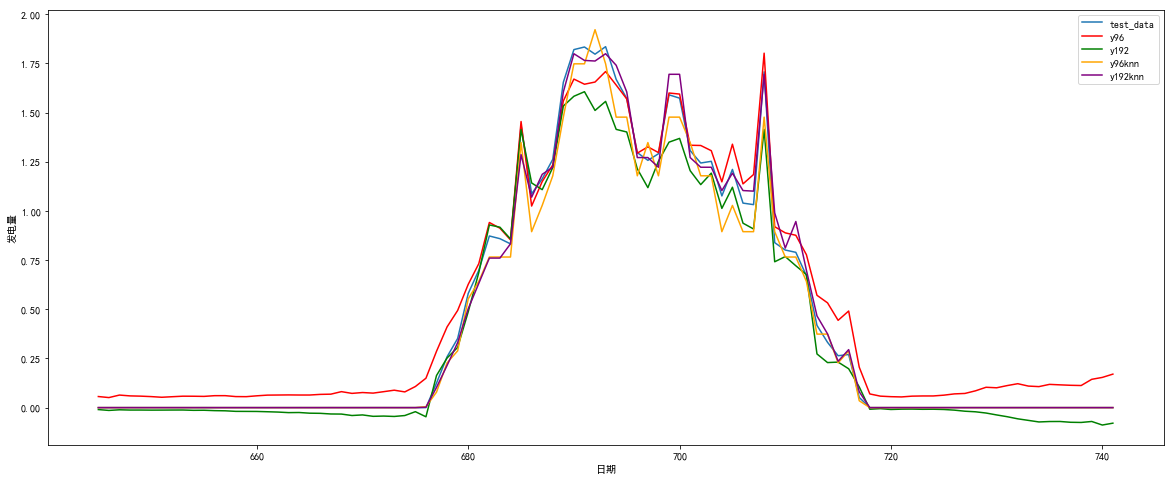

In [142]:
fig = plt.figure(figsize=(20,8))
plt.plot(aa[645:].index,y[645:],label='test_data')
plt.plot(aa[645:].index,y96,color='red',label='y96')
plt.plot(aa[645:].index,y192,color='green',label='y192')
plt.plot(aa[645:].index,y96knn,color='orange',label='y96knn')
plt.plot(aa[645:].index,y192knn,color='purple',label='y192knn')
plt.xlabel("日期")
plt.ylabel("发电量")
plt.legend()
plt.savefig('yTotal.png')
# plt.rcParams['figure.figsize'] = (200.0, 200.0) # 单位是inches
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.show()

In [202]:
C=[[nmse1*100,mae1*100,r2_1],[nmse2*100,mae2*100,r2_2],[nmse3*100,mae3*100,r2_3],[nmse4*100,mae4*100,r2_4]]
chart=pd.DataFrame(C,index=['神经网络_一天数据', '神经网络_两天数据', 'KNN_一天数据','KNN_两天数据'],columns=['NMSE(%)', 'MAE(%)', 'R2'])
# print(chart)
chart.head()

,NMSE(%),MAE(%),R2
神经网络_一天数据,10.914170,5.942341,0.968675
神经网络_两天数据,6.534985,3.459583,0.988769
KNN_一天数据,6.868969,3.832765,0.987592
KNN_两天数据,4.250837,2.187100,0.995248


UsageError: %%writefile is a cell magic, but the cell body is empty.
